# Projet : Prédiction du Genre des Films avec Naive Bayes

## Contexte
Dans ce projet, l'objectif est de prédire le genre d'un film en fonction de ses caractéristiques numériques :
- **Votes** : Le nombre de votes que le film a reçus
- **Popularité** : Un score représentant la popularité du film
- **Rating** : La note moyenne du film

Nous utiliserons un modèle de **Naive Bayes** pour effectuer cette classification multi-classes.

### Étapes du projet :
1. Téléchargement et chargement des données IMDb
2. Préparation et nettoyage des données
3. Exploration des données (EDA)
4. Séparation en ensembles d'entraînement et de test
5. Entraînement du modèle Naive Bayes
6. Évaluation des performances
7. Analyse des résultats

## 1. Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 2. Chargement des données

Nous allons créer un jeu de données simulé basé sur les caractéristiques typiques des films IMDb.
Dans un cas réel, vous téléchargeriez le dataset depuis [Kaggle - IMDB Movies Dataset](https://www.kaggle.com/datasets/ashirwadsangwan/imdb-dataset).

**Note:** Si vous avez le vrai dataset, remplacez la cellule suivante par:
```python
df = pd.read_csv('chemin/vers/imdb_movies.csv')
```

In [2]:
# Option 1: Charger un dataset réel (décommentez si vous avez le fichier)
# df = pd.read_csv('imdb_movies.csv')

# Option 2: Créer un dataset simulé pour la démonstration
np.random.seed(42)

# Définir les genres et leurs caractéristiques typiques
genres = ['Action', 'Comedy', 'Drama', 'Horror', 'Sci-Fi', 'Romance']
n_samples_per_genre = 500

# Caractéristiques moyennes par genre (votes, popularity, rating)
genre_characteristics = {
    'Action': {'votes_mean': 150000, 'votes_std': 80000, 'pop_mean': 70, 'pop_std': 15, 'rating_mean': 6.5, 'rating_std': 1.0},
    'Comedy': {'votes_mean': 80000, 'votes_std': 50000, 'pop_mean': 55, 'pop_std': 20, 'rating_mean': 6.0, 'rating_std': 1.2},
    'Drama': {'votes_mean': 100000, 'votes_std': 60000, 'pop_mean': 60, 'pop_std': 18, 'rating_mean': 7.0, 'rating_std': 0.9},
    'Horror': {'votes_mean': 60000, 'votes_std': 40000, 'pop_mean': 45, 'pop_std': 15, 'rating_mean': 5.5, 'rating_std': 1.3},
    'Sci-Fi': {'votes_mean': 130000, 'votes_std': 70000, 'pop_mean': 65, 'pop_std': 18, 'rating_mean': 6.8, 'rating_std': 1.1},
    'Romance': {'votes_mean': 50000, 'votes_std': 30000, 'pop_mean': 40, 'pop_std': 15, 'rating_mean': 6.2, 'rating_std': 1.0}
}

# Générer les données
data = []
for genre in genres:
    chars = genre_characteristics[genre]
    for _ in range(n_samples_per_genre):
        votes = max(1000, np.random.normal(chars['votes_mean'], chars['votes_std']))
        popularity = max(1, min(100, np.random.normal(chars['pop_mean'], chars['pop_std'])))
        rating = max(1, min(10, np.random.normal(chars['rating_mean'], chars['rating_std'])))
        data.append({'Votes': int(votes), 'Popularity': popularity, 'Rating': rating, 'Genre': genre})

df = pd.DataFrame(data)

print("="*60)
print("DATASET CHARGÉ AVEC SUCCÈS")
print("="*60)
print(f"\nNombre total de films: {len(df)}")
print(f"\nColonnes: {list(df.columns)}")
print(f"\nAperçu des données:")
df.head(10)

DATASET CHARGÉ AVEC SUCCÈS

Nombre total de films: 3000

Colonnes: ['Votes', 'Popularity', 'Rating', 'Genre']

Aperçu des données:


,Votes,Popularity,Rating,Genre
0,189737,67.926035,7.147689,Action
1,271842,66.487699,6.265863,Action
2,276337,81.511521,6.030526,Action
3,193404,63.048735,6.034270,Action
4,169356,41.300796,4.775082,Action
5,105016,54.807533,6.814247,Action
6,77358,48.815444,7.965649,Action
7,131937,71.012923,5.075252,Action
8,106449,71.663839,5.349006,Action
9,180055,60.990420,6.208306,Action


## 3. Exploration des données (EDA)

In [3]:
# Informations générales sur le dataset
print("="*60)
print("INFORMATIONS SUR LE DATASET")
print("="*60)
print(df.info())

print("\n" + "="*60)
print("STATISTIQUES DESCRIPTIVES")
print("="*60)
df.describe()

INFORMATIONS SUR LE DATASET
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Votes       3000 non-null   int64  
 1   Popularity  3000 non-null   float64
 2   Rating      3000 non-null   float64
 3   Genre       3000 non-null   str    
dtypes: float64(2), int64(1), str(1)
memory usage: 93.9 KB
None

STATISTIQUES DESCRIPTIVES


,Votes,Popularity,Rating
count,3000.000000,3000.000000,3000.000000
mean,95769.671000,55.319526,6.368949
std,66832.004793,19.847275,1.200558
min,1000.000000,1.000000,1.817061
25%,47368.750000,41.201378,5.597366
50%,83141.500000,55.076541,6.407492
75%,134293.750000,68.844038,7.175102
max,377033.000000,100.000000,10.000000



Distribution des genres:
Genre
Action     500
Comedy     500
Drama      500
Horror     500
Sci-Fi     500
Romance    500
Name: count, dtype: int64


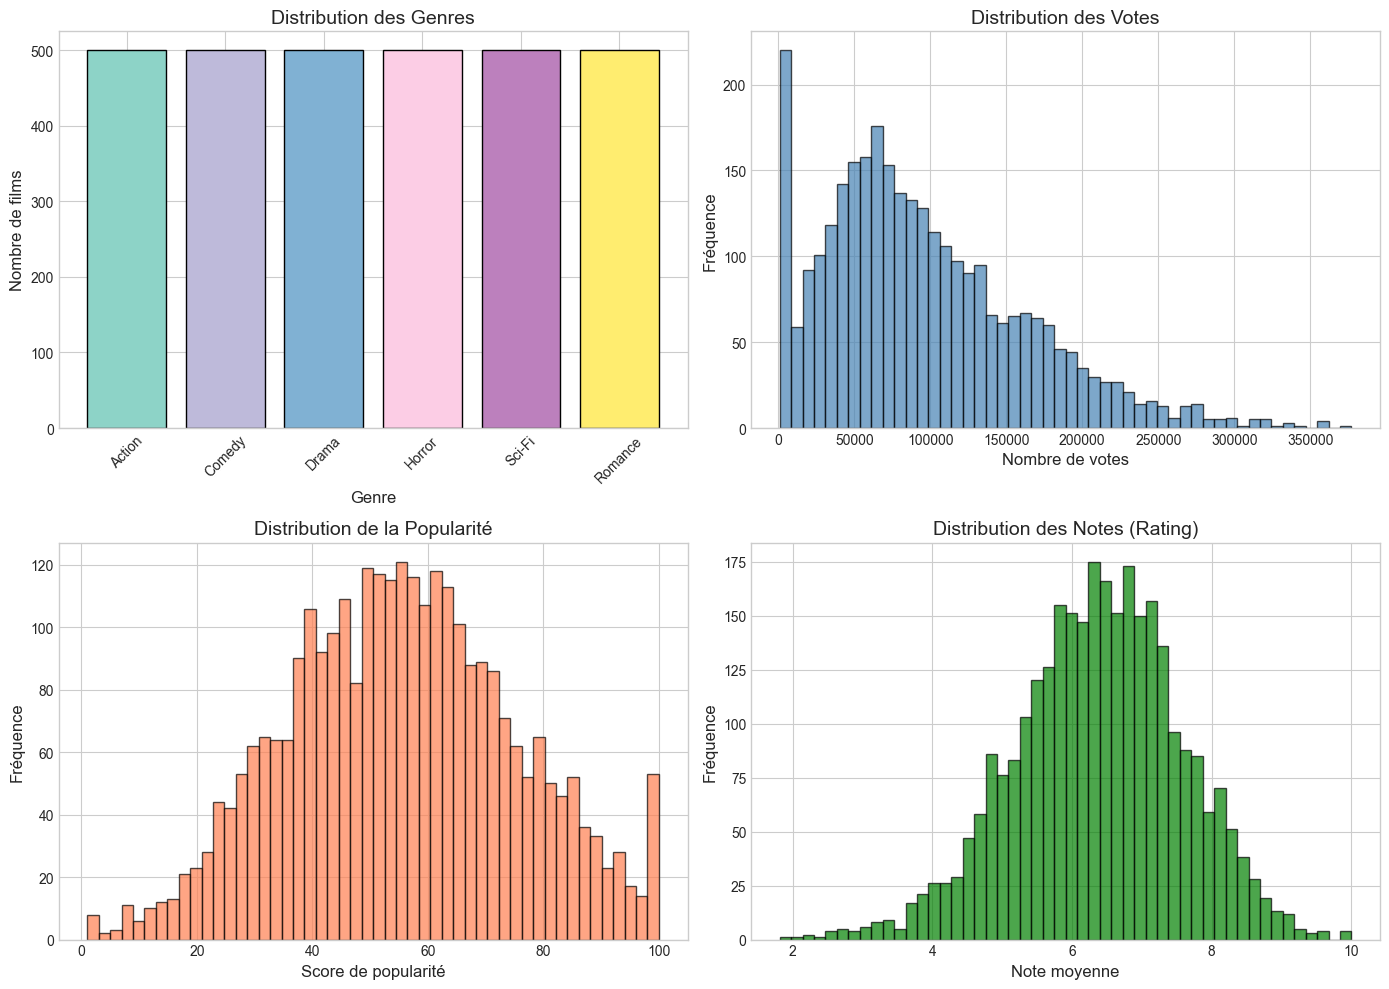

In [4]:
# Distribution des genres
print("\nDistribution des genres:")
print(df['Genre'].value_counts())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution des genres
ax1 = axes[0, 0]
genre_counts = df['Genre'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(genre_counts)))
ax1.bar(genre_counts.index, genre_counts.values, color=colors, edgecolor='black')
ax1.set_xlabel('Genre', fontsize=12)
ax1.set_ylabel('Nombre de films', fontsize=12)
ax1.set_title('Distribution des Genres', fontsize=14)
ax1.tick_params(axis='x', rotation=45)

# Distribution des votes
ax2 = axes[0, 1]
df['Votes'].hist(bins=50, ax=ax2, color='steelblue', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Nombre de votes', fontsize=12)
ax2.set_ylabel('Fréquence', fontsize=12)
ax2.set_title('Distribution des Votes', fontsize=14)

# Distribution de la popularité
ax3 = axes[1, 0]
df['Popularity'].hist(bins=50, ax=ax3, color='coral', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Score de popularité', fontsize=12)
ax3.set_ylabel('Fréquence', fontsize=12)
ax3.set_title('Distribution de la Popularité', fontsize=14)

# Distribution des ratings
ax4 = axes[1, 1]
df['Rating'].hist(bins=50, ax=ax4, color='green', edgecolor='black', alpha=0.7)
ax4.set_xlabel('Note moyenne', fontsize=12)
ax4.set_ylabel('Fréquence', fontsize=12)
ax4.set_title('Distribution des Notes (Rating)', fontsize=14)

plt.tight_layout()
plt.show()

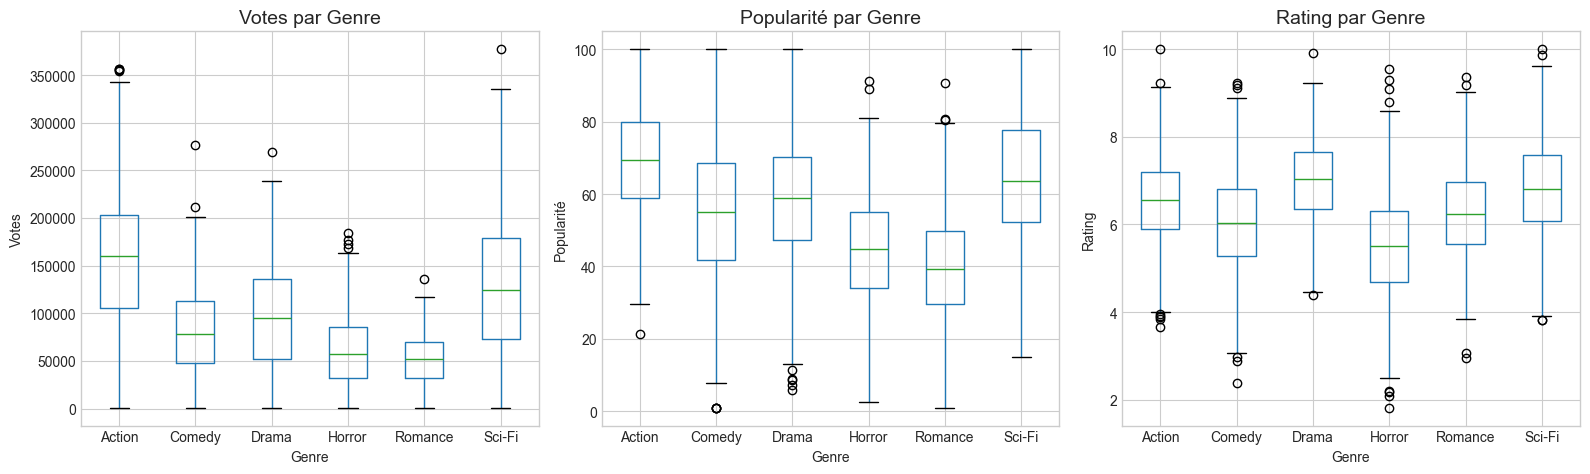

In [5]:
# Boxplots par genre
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Votes par genre
df.boxplot(column='Votes', by='Genre', ax=axes[0])
axes[0].set_title('Votes par Genre', fontsize=14)
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Votes')

# Popularité par genre
df.boxplot(column='Popularity', by='Genre', ax=axes[1])
axes[1].set_title('Popularité par Genre', fontsize=14)
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Popularité')

# Rating par genre
df.boxplot(column='Rating', by='Genre', ax=axes[2])
axes[2].set_title('Rating par Genre', fontsize=14)
axes[2].set_xlabel('Genre')
axes[2].set_ylabel('Rating')

plt.suptitle('')  # Supprimer le titre automatique
plt.tight_layout()
plt.show()

In [6]:
# Statistiques par genre
print("="*70)
print("STATISTIQUES PAR GENRE")
print("="*70)
stats_by_genre = df.groupby('Genre').agg({
    'Votes': ['mean', 'std', 'min', 'max'],
    'Popularity': ['mean', 'std', 'min', 'max'],
    'Rating': ['mean', 'std', 'min', 'max']
}).round(2)
print(stats_by_genre)

STATISTIQUES PAR GENRE
             Votes                         Popularity                        \
              mean       std   min     max       mean    std    min     max   
Genre                                                                         
Action   159525.95  74154.34  1000  356376      69.44  14.64  21.38  100.00   
Comedy    81111.15  47214.37  1000  276311      55.15  19.81   1.00  100.00   
Drama     95247.48  58063.36  1000  268879      58.97  17.94   5.86  100.00   
Horror    59937.48  38406.05  1000  183931      44.17  14.64   2.52   91.15   
Romance   51383.87  28346.64  1000  135956      39.92  14.88   1.00   90.66   
Sci-Fi   127412.10  70096.22  1000  377033      64.28  18.64  15.07  100.00   

        Rating                     
          mean   std   min    max  
Genre                              
Action    6.56  1.03  3.65  10.00  
Comedy    6.04  1.12  2.38   9.23  
Drama     7.03  0.91  4.38   9.92  
Horror    5.50  1.29  1.82   9.55  
Romance   6.2

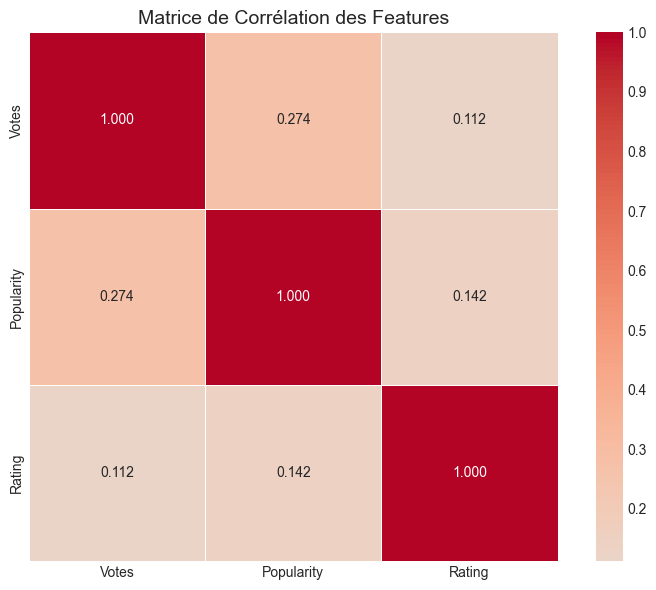

In [7]:
# Matrice de corrélation
fig, ax = plt.subplots(figsize=(8, 6))
correlation_matrix = df[['Votes', 'Popularity', 'Rating']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=ax,
            fmt='.3f', square=True, linewidths=0.5)
ax.set_title('Matrice de Corrélation des Features', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Préparation des données

In [8]:
# Encoder les genres en valeurs numériques
label_encoder = LabelEncoder()
df['Genre_encoded'] = label_encoder.fit_transform(df['Genre'])

print("Encodage des genres:")
for i, genre in enumerate(label_encoder.classes_):
    print(f"  {genre} = {i}")

# Définir les features (X) et la cible (y)
X = df[['Votes', 'Popularity', 'Rating']].values
y = df['Genre_encoded'].values

print(f"\nShape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

Encodage des genres:
  Action = 0
  Comedy = 1
  Drama = 2
  Horror = 3
  Romance = 4
  Sci-Fi = 5

Shape de X: (3000, 3)
Shape de y: (3000,)


In [9]:
# Normalisation des features (important pour certains algorithmes)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features normalisées:")
print(f"  Moyenne: {X_scaled.mean(axis=0)}")
print(f"  Écart-type: {X_scaled.std(axis=0)}")

Features normalisées:
  Moyenne: [-5.68434189e-17  2.84217094e-16 -1.89478063e-17]
  Écart-type: [1. 1. 1.]


## 5. Séparation des données en ensembles d'entraînement et de test

In [10]:
# Diviser les données: 80% entraînement, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("="*60)
print("SÉPARATION DES DONNÉES")
print("="*60)
print(f"\nEnsemble d'entraînement: {len(X_train)} échantillons ({len(X_train)/len(X)*100:.1f}%)")
print(f"Ensemble de test: {len(X_test)} échantillons ({len(X_test)/len(X)*100:.1f}%)")

# Vérifier la distribution des classes
print("\nDistribution des genres dans l'ensemble d'entraînement:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_encoder.classes_[u]}: {c} ({c/len(y_train)*100:.1f}%)")

SÉPARATION DES DONNÉES

Ensemble d'entraînement: 2400 échantillons (80.0%)
Ensemble de test: 600 échantillons (20.0%)

Distribution des genres dans l'ensemble d'entraînement:
  Action: 400 (16.7%)
  Comedy: 400 (16.7%)
  Drama: 400 (16.7%)
  Horror: 400 (16.7%)
  Romance: 400 (16.7%)
  Sci-Fi: 400 (16.7%)


## 6. Entraînement du modèle Naive Bayes

In [11]:
# Créer et entraîner le modèle Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)

print("="*60)
print("MODÈLE NAIVE BAYES ENTRAÎNÉ")
print("="*60)

# Afficher les paramètres appris
print("\nParamètres appris par le modèle:")
print("\nProbabilités a priori (Prior) pour chaque classe:")
for i, prior in enumerate(gnb.class_prior_):
    print(f"  {label_encoder.classes_[i]}: {prior:.4f}")

print("\nMoyennes des features pour chaque classe:")
feature_names = ['Votes', 'Popularity', 'Rating']
means_df = pd.DataFrame(gnb.theta_, columns=feature_names, index=label_encoder.classes_)
print(means_df.round(4))

print("\nVariances des features pour chaque classe:")
var_df = pd.DataFrame(gnb.var_, columns=feature_names, index=label_encoder.classes_)
print(var_df.round(4))

MODÈLE NAIVE BAYES ENTRAÎNÉ

Paramètres appris par le modèle:

Probabilités a priori (Prior) pour chaque classe:
  Action: 0.1667
  Comedy: 0.1667
  Drama: 0.1667
  Horror: 0.1667
  Romance: 0.1667
  Sci-Fi: 0.1667

Moyennes des features pour chaque classe:
          Votes  Popularity  Rating
Action   0.9135      0.7210  0.1757
Comedy  -0.2366     -0.0061 -0.2914
Drama    0.0087      0.1783  0.5785
Horror  -0.5517     -0.5687 -0.7468
Romance -0.6690     -0.7482 -0.0683
Sci-Fi   0.4894      0.4503  0.3780

Variances des features pour chaque classe:
          Votes  Popularity  Rating
Action   1.2395      0.5581  0.7282
Comedy   0.5138      1.0210  0.8925
Drama    0.7662      0.7954  0.5723
Horror   0.3253      0.5576  1.1854
Romance  0.1787      0.5615  0.7981
Sci-Fi   1.1413      0.8788  0.8035


In [12]:
# Faire des prédictions
y_pred = gnb.predict(X_test)
y_pred_proba = gnb.predict_proba(X_test)

print("Prédictions effectuées!")
print(f"\nExemple de probabilités de prédiction (premier film):")
for i, genre in enumerate(label_encoder.classes_):
    print(f"  P({genre}) = {y_pred_proba[0][i]:.4f}")

Prédictions effectuées!

Exemple de probabilités de prédiction (premier film):
  P(Action) = 0.1916
  P(Comedy) = 0.2221
  P(Drama) = 0.2981
  P(Horror) = 0.0255
  P(Romance) = 0.0350
  P(Sci-Fi) = 0.2276


## 7. Évaluation des performances

In [13]:
# Calculer les métriques de performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("="*60)
print("MÉTRIQUES DE PERFORMANCE")
print("="*60)
print(f"\nAccuracy (Exactitude):    {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision (Précision):    {precision:.4f}")
print(f"Recall (Rappel):          {recall:.4f}")
print(f"F1-Score:                 {f1:.4f}")

MÉTRIQUES DE PERFORMANCE

Accuracy (Exactitude):    0.4200 (42.00%)
Precision (Précision):    0.4382
Recall (Rappel):          0.4200
F1-Score:                 0.4010


In [14]:
# Rapport de classification détaillé
print("\n" + "="*60)
print("RAPPORT DE CLASSIFICATION DÉTAILLÉ")
print("="*60)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


RAPPORT DE CLASSIFICATION DÉTAILLÉ
              precision    recall  f1-score   support

      Action       0.50      0.59      0.54       100
      Comedy       0.31      0.28      0.29       100
       Drama       0.33      0.47      0.39       100
      Horror       0.50      0.36      0.42       100
     Romance       0.45      0.68      0.54       100
      Sci-Fi       0.54      0.14      0.22       100

    accuracy                           0.42       600
   macro avg       0.44      0.42      0.40       600
weighted avg       0.44      0.42      0.40       600



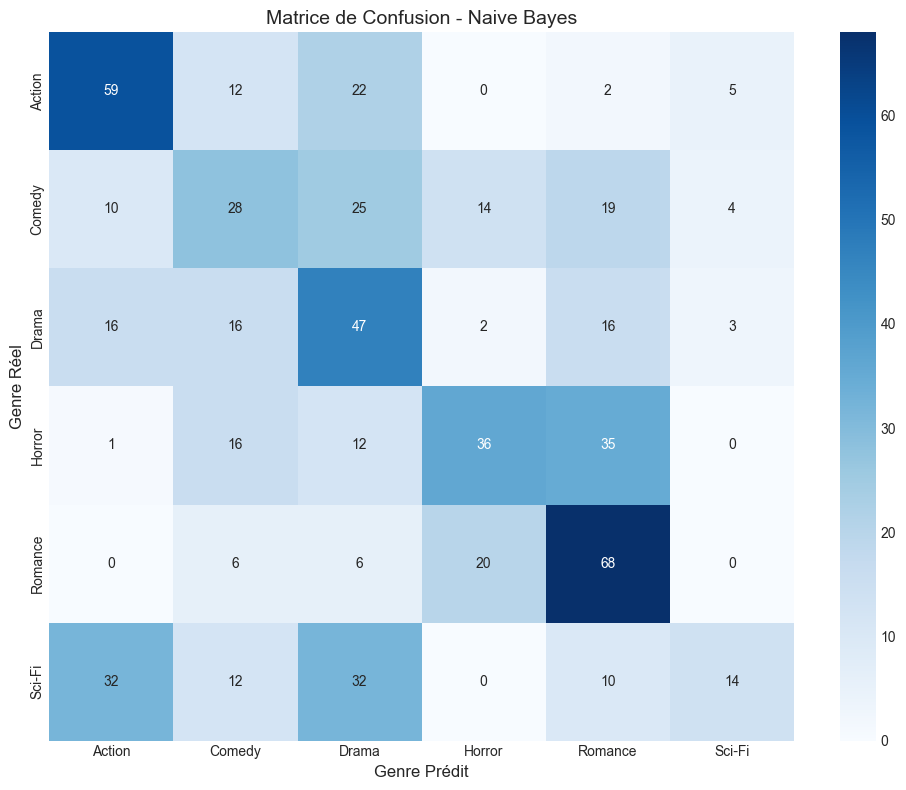


Nombre de prédictions correctes par genre:
  Action: 59/100 (59.0%)
  Comedy: 28/100 (28.0%)
  Drama: 47/100 (47.0%)
  Horror: 36/100 (36.0%)
  Romance: 68/100 (68.0%)
  Sci-Fi: 14/100 (14.0%)


In [15]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=ax)
ax.set_xlabel('Genre Prédit', fontsize=12)
ax.set_ylabel('Genre Réel', fontsize=12)
ax.set_title('Matrice de Confusion - Naive Bayes', fontsize=14)
plt.tight_layout()
plt.show()

# Afficher les erreurs principales
print("\nNombre de prédictions correctes par genre:")
for i, genre in enumerate(label_encoder.classes_):
    correct = cm[i, i]
    total = cm[i, :].sum()
    print(f"  {genre}: {correct}/{total} ({correct/total*100:.1f}%)")

## 8. Analyse des résultats

In [16]:
# Analyse des erreurs de classification
print("="*60)
print("ANALYSE DES ERREURS")
print("="*60)

# Identifier les mauvaises prédictions
incorrect_mask = y_test != y_pred
incorrect_indices = np.where(incorrect_mask)[0]

print(f"\nNombre total d'erreurs: {len(incorrect_indices)} / {len(y_test)} ({len(incorrect_indices)/len(y_test)*100:.1f}%)")

# Analyser les confusions les plus fréquentes
print("\nConfusions les plus fréquentes:")
confusion_pairs = {}
for true, pred in zip(y_test[incorrect_mask], y_pred[incorrect_mask]):
    pair = (label_encoder.classes_[true], label_encoder.classes_[pred])
    confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1

sorted_confusions = sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)
for (true_genre, pred_genre), count in sorted_confusions[:10]:
    print(f"  {true_genre} → {pred_genre}: {count} erreurs")

ANALYSE DES ERREURS

Nombre total d'erreurs: 348 / 600 (58.0%)

Confusions les plus fréquentes:
  Horror → Romance: 35 erreurs
  Sci-Fi → Drama: 32 erreurs
  Sci-Fi → Action: 32 erreurs
  Comedy → Drama: 25 erreurs
  Action → Drama: 22 erreurs
  Romance → Horror: 20 erreurs
  Comedy → Romance: 19 erreurs
  Drama → Romance: 16 erreurs
  Drama → Comedy: 16 erreurs
  Horror → Comedy: 16 erreurs



PERFORMANCE PAR GENRE
  Genre  Precision  Recall  F1-Score
 Action     0.5000    0.59    0.5413
 Comedy     0.3111    0.28    0.2947
  Drama     0.3264    0.47    0.3852
 Horror     0.5000    0.36    0.4186
Romance     0.4533    0.68    0.5440
 Sci-Fi     0.5385    0.14    0.2222


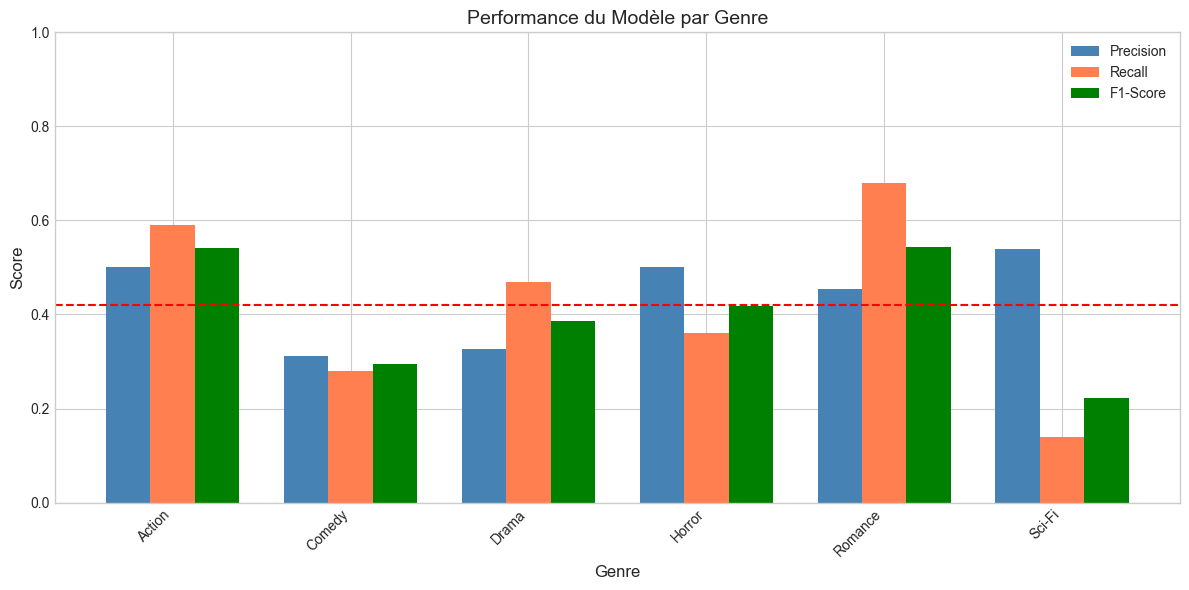

In [17]:
# Performance par genre
print("\n" + "="*60)
print("PERFORMANCE PAR GENRE")
print("="*60)

# Calculer les métriques par classe
precision_per_class = precision_score(y_test, y_pred, average=None)
recall_per_class = recall_score(y_test, y_pred, average=None)
f1_per_class = f1_score(y_test, y_pred, average=None)

performance_df = pd.DataFrame({
    'Genre': label_encoder.classes_,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class
}).round(4)

print(performance_df.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(label_encoder.classes_))
width = 0.25

bars1 = ax.bar(x - width, precision_per_class, width, label='Precision', color='steelblue')
bars2 = ax.bar(x, recall_per_class, width, label='Recall', color='coral')
bars3 = ax.bar(x + width, f1_per_class, width, label='F1-Score', color='green')

ax.set_xlabel('Genre', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance du Modèle par Genre', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(label_encoder.classes_, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.axhline(y=accuracy, color='red', linestyle='--', label=f'Accuracy globale: {accuracy:.2f}')

plt.tight_layout()
plt.show()

In [18]:
# Exemples de prédictions
print("\n" + "="*60)
print("EXEMPLES DE PRÉDICTIONS")
print("="*60)

# Sélectionner quelques exemples aléatoires
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), size=10, replace=False)

print(f"\n{'Votes':>10} {'Popularity':>12} {'Rating':>8} {'Vrai Genre':>12} {'Prédit':>12} {'Correct':>10}")
print("-" * 70)

# Inverser la normalisation pour afficher les vraies valeurs
X_test_original = scaler.inverse_transform(X_test)

for idx in sample_indices:
    votes, popularity, rating = X_test_original[idx]
    true_genre = label_encoder.classes_[y_test[idx]]
    pred_genre = label_encoder.classes_[y_pred[idx]]
    correct = "✓" if true_genre == pred_genre else "✗"
    print(f"{votes:>10.0f} {popularity:>12.1f} {rating:>8.1f} {true_genre:>12} {pred_genre:>12} {correct:>10}")


EXEMPLES DE PRÉDICTIONS

     Votes   Popularity   Rating   Vrai Genre       Prédit    Correct
----------------------------------------------------------------------
     80010         54.8      5.6       Comedy       Horror          ✗
    245603         47.2      5.9       Action       Action          ✓
    114178         27.7      7.5       Comedy        Drama          ✗
     12446         28.6      6.6       Comedy      Romance          ✗
    116567         51.7      4.8       Horror       Comedy          ✗
    174583         82.2      7.1       Action       Action          ✓
     36694         62.3      6.1        Drama      Romance          ✗
    246097         63.9      4.5       Action       Action          ✓
    187731         68.1      7.9        Drama       Action          ✗
    120689         41.2      9.2       Sci-Fi        Drama          ✗


## 9. Conclusions

In [19]:
print("="*70)
print("CONCLUSIONS")
print("="*70)

print(f"""
RÉSUMÉ DU PROJET
----------------
1. Dataset: {len(df)} films avec {len(genres)} genres différents
   - Features utilisées: Votes, Popularité, Rating
   - Variable cible: Genre du film

2. Modèle: Gaussian Naive Bayes
   - Hypothèse: Les features suivent une distribution gaussienne
   - Hypothèse d'indépendance conditionnelle entre les features

3. Performance globale:
   - Accuracy: {accuracy:.2%}
   - F1-Score moyen: {f1:.4f}

4. Observations:
   - Le modèle performe différemment selon les genres
   - Les genres avec des caractéristiques distinctes sont mieux classés
   - Certains genres sont souvent confondus (caractéristiques similaires)

5. Limites de l'approche:
   - L'hypothèse d'indépendance des features n'est pas toujours vraie
   - Les caractéristiques numériques seules ne capturent pas toute
     l'information nécessaire pour classifier les genres
   - D'autres features (synopsis, acteurs, réalisateur) pourraient améliorer
     les performances

6. Améliorations possibles:
   - Ajouter plus de features (durée, budget, année, etc.)
   - Utiliser des techniques de text mining sur le synopsis
   - Essayer d'autres algorithmes (Random Forest, SVM, Neural Networks)
   - Faire du feature engineering plus poussé
""")

CONCLUSIONS

RÉSUMÉ DU PROJET
----------------
1. Dataset: 3000 films avec 6 genres différents
   - Features utilisées: Votes, Popularité, Rating
   - Variable cible: Genre du film

2. Modèle: Gaussian Naive Bayes
   - Hypothèse: Les features suivent une distribution gaussienne
   - Hypothèse d'indépendance conditionnelle entre les features

3. Performance globale:
   - Accuracy: 42.00%
   - F1-Score moyen: 0.4010

4. Observations:
   - Le modèle performe différemment selon les genres
   - Les genres avec des caractéristiques distinctes sont mieux classés
   - Certains genres sont souvent confondus (caractéristiques similaires)

5. Limites de l'approche:
   - L'hypothèse d'indépendance des features n'est pas toujours vraie
   - Les caractéristiques numériques seules ne capturent pas toute
     l'information nécessaire pour classifier les genres
   - D'autres features (synopsis, acteurs, réalisateur) pourraient améliorer
     les performances

6. Améliorations possibles:
   - Ajouter pl

## 10. Test avec de nouveaux films (exemple)

In [20]:
# Fonction pour prédire le genre d'un nouveau film
def predict_movie_genre(votes, popularity, rating):
    """
    Prédit le genre d'un film basé sur ses caractéristiques.
    
    Args:
        votes: Nombre de votes
        popularity: Score de popularité (1-100)
        rating: Note moyenne (1-10)
    
    Returns:
        Genre prédit et probabilités pour chaque genre
    """
    # Préparer les données
    features = np.array([[votes, popularity, rating]])
    features_scaled = scaler.transform(features)
    
    # Prédiction
    prediction = gnb.predict(features_scaled)[0]
    probabilities = gnb.predict_proba(features_scaled)[0]
    
    predicted_genre = label_encoder.classes_[prediction]
    
    return predicted_genre, dict(zip(label_encoder.classes_, probabilities))

# Test avec quelques films hypothétiques
print("="*60)
print("TEST AVEC DE NOUVEAUX FILMS")
print("="*60)

test_movies = [
    ("Film blockbuster d'action", 200000, 85, 7.5),
    ("Petite comédie indépendante", 30000, 30, 6.8),
    ("Film d'horreur classique", 50000, 40, 5.0),
    ("Drame acclamé par la critique", 120000, 70, 8.5),
]

for name, votes, pop, rating in test_movies:
    genre, probs = predict_movie_genre(votes, pop, rating)
    print(f"\n{name}")
    print(f"  Caractéristiques: Votes={votes}, Popularité={pop}, Rating={rating}")
    print(f"  Genre prédit: {genre}")
    print(f"  Probabilités:")
    for g, p in sorted(probs.items(), key=lambda x: x[1], reverse=True):
        print(f"    {g}: {p:.2%}")

TEST AVEC DE NOUVEAUX FILMS

Film blockbuster d'action
  Caractéristiques: Votes=200000, Popularité=85, Rating=7.5
  Genre prédit: Action
  Probabilités:
    Action: 53.03%
    Sci-Fi: 33.91%
    Drama: 12.03%
    Comedy: 1.02%
    Horror: 0.00%
    Romance: 0.00%

Petite comédie indépendante
  Caractéristiques: Votes=30000, Popularité=30, Rating=6.8
  Genre prédit: Romance
  Probabilités:
    Romance: 60.14%
    Horror: 19.91%
    Comedy: 9.81%
    Drama: 7.29%
    Sci-Fi: 2.55%
    Action: 0.29%

Film d'horreur classique
  Caractéristiques: Votes=50000, Popularité=40, Rating=5.0
  Genre prédit: Horror
  Probabilités:
    Horror: 43.55%
    Romance: 39.49%
    Comedy: 13.84%
    Sci-Fi: 1.42%
    Drama: 1.22%
    Action: 0.48%

Drame acclamé par la critique
  Caractéristiques: Votes=120000, Popularité=70, Rating=8.5
  Genre prédit: Drama
  Probabilités:
    Drama: 37.46%
    Sci-Fi: 32.01%
    Action: 22.00%
    Comedy: 7.33%
    Horror: 0.90%
    Romance: 0.30%
